Download the data set

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("superpotato9/dalle-recognition-dataset")

# print("Path to dataset files:", path)

Import Needed Dependencies

In [3]:
import tensorflow as tf
import os

In [4]:
import imghdr
import cv2

C:\Users\Divino\AppData\Local\Temp\ipykernel_4628\207333208.py:1: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [5]:
data_dir = 'data'

In [6]:
os.listdir(os.path.join(data_dir, "fake-v2"))

['1.jpg',
 '10.jpg',
 '1000.jpg',
 '10000.jpg',
 '10001.jpg',
 '10002.jpg',
 '10003.jpg',
 '10004.jpg',
 '10005.jpg',
 '10006.jpg',
 '10007.jpg',
 '10008.jpg',
 '10009.jpg',
 '1001.jpg',
 '10010.jpg',
 '10011.jpg',
 '10012.jpg',
 '10013.jpg',
 '10014.jpg',
 '10015.jpg',
 '10016.jpg',
 '10017.jpg',
 '10018.jpg',
 '10019.jpg',
 '1002.jpg',
 '10020.jpg',
 '10021.jpg',
 '10022.jpg',
 '10023.jpg',
 '10024.jpg',
 '10025.jpg',
 '10026.jpg',
 '10027.jpg',
 '10028.jpg',
 '10029.jpg',
 '1003.jpg',
 '10030.jpg',
 '10031.jpg',
 '10032.jpg',
 '10033.jpg',
 '10034.jpg',
 '10035.jpg',
 '10036.jpg',
 '10037.jpg',
 '10038.jpg',
 '10039.jpg',
 '1004.jpg',
 '10040.jpg',
 '10041.jpg',
 '10042.jpg',
 '10043.jpg',
 '10044.jpg',
 '10045.jpg',
 '10046.jpg',
 '10047.jpg',
 '10048.jpg',
 '10049.jpg',
 '1005.jpg',
 '10050.jpg',
 '10051.jpg',
 '10052.jpg',
 '10053.jpg',
 '10054.jpg',
 '10055.jpg',
 '10056.jpg',
 '10057.jpg',
 '10058.jpg',
 '10059.jpg',
 '1006.jpg',
 '10060.jpg',
 '10061.jpg',
 '10062.jpg',
 '1006

In [7]:
image_exts = ['jpeg', 'jpg', 'png']

Converting image to a numpy array

In [8]:
# img = cv2.imread(os.path.join('data', 'real', '0.jpg'))

Removing not needed images:

In [9]:
# for image_class in os.listdir(data_dir):
#     for image in os.listdir(os.path.join(data_dir, image_class)):
#         image_path = os.path.join (data_dir, image_class, image)
#         try:
#             img = cv2.imread(image_path)
#             tip = imghdr.what(image_path)
#             if tip not in image_exts:
#                 print('Image not in ext list {}'.format(image_path))
#                 os.remove(image_path)
#         except Exception as e:
#             print(f"Issue with image {image_path}")

Loading the data

In [10]:
import numpy as np
from matplotlib import pyplot as plt

Building data pipeline:

In [11]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 21587 files belonging to 2 classes.


Accessing data pipeline:

In [12]:
#To get another batch from the iterator
data_iterator = data.as_numpy_iterator()

In [13]:
batch = data_iterator.next()

Images represented as numpy arrays:

In [14]:
batch[0].shape

(32, 256, 256, 3)

Image classes:
CLASS 0 = AI GENERATED
CLASS 1 = REAL IMAGES

In [15]:
batch[1]

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1], dtype=int32)

Plotting each class of images:

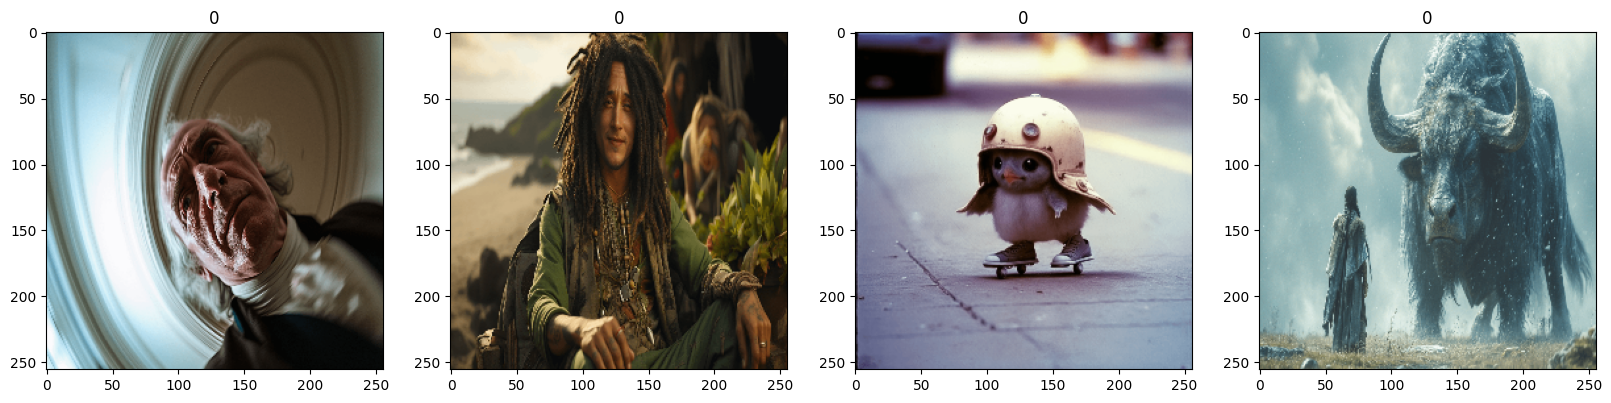

In [16]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [17]:
scaled = batch[0] / 255


## PREPROCESSING DATA

### Scale the data

In [18]:
data = data.map(lambda x, y: (x/255, y))


In [19]:
scaled_iterator = data.as_numpy_iterator()

In [20]:
batch = scaled_iterator.next()

In [21]:
batch[0].min()

np.float32(0.0)

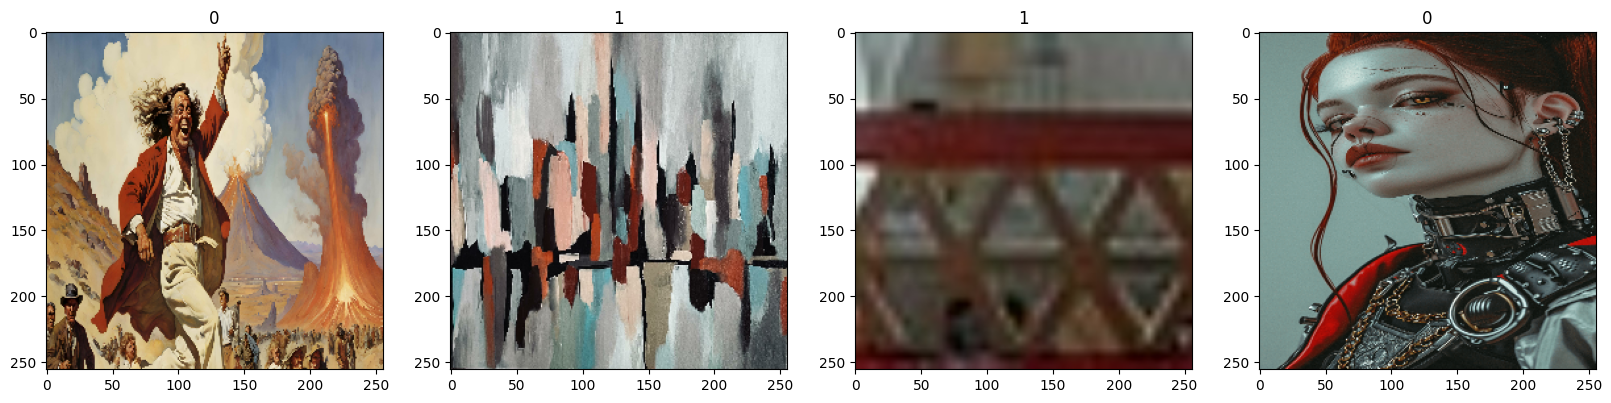

In [22]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

### Split the data

In [23]:
len(data)

675

In [24]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.15)+1
test_size = int(len(data)*.15)

In [25]:
train_size+val_size+test_size

675

In [26]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [27]:
X_train = train.map(lambda x, y: x)
y_train = train.map(lambda x, y: y)

In [28]:
X_val = val.map(lambda x, y: x)
y_val = val.map(lambda x, y: y)

In [29]:
X_test = test.map(lambda x, y: x)
y_test = test.map(lambda x, y: y)

In [32]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Assuming data is a tf.data.Dataset object
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

# Function to extract labels from the dataset
def extract_labels(dataset):
    labels = []
    for _, label in dataset:
        labels.append(label.numpy())
    return np.concatenate(labels)

# Extract labels from the train dataset
y_train = extract_labels(train)

# Ensure y_train is a flat array
y_train = y_train.flatten()

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Define your model architecture with an Input layer
model = Sequential([
    Input(shape=(256, 256, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
])

# Compile the model with a suitable optimizer and loss function
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

# Define callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

# Train the model using the tf.data.Dataset objects directly
history = model.fit(
    train,
    epochs=50,
    validation_data=val,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weight_dict
)

Epoch 1/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1169s 2s/step - accuracy: 0.5875 - loss: 0.8650 - val_accuracy: 0.5444 - val_loss: 0.7119 - learning_rate: 1.0000e-04
Epoch 2/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1191s 3s/step - accuracy: 0.7322 - loss: 0.6001 - val_accuracy: 0.7099 - val_loss: 0.6570 - learning_rate: 1.0000e-04
Epoch 3/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1205s 3s/step - accuracy: 0.7929 - loss: 0.5493 - val_accuracy: 0.8217 - val_loss: 0.6260 - learning_rate: 1.0000e-04
Epoch 4/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 1073s 2s/step - accuracy: 0.8191 - loss: 0.5093 - val_accuracy: 0.7868 - val_loss: 0.6425 - learning_rate: 1.0000e-04
Epoch 5/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 961s 2s/step - accuracy: 0.8327 - loss: 0.4789 - val_accuracy: 0.8499 - val_loss: 0.5698 - learning_rate: 1.0000e-04
Epoch 6/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 960s 2s/step - accuracy: 0.8493 - loss: 0.4536 - val_accuracy: 0.8640 - val_loss: 0.5412 - learning_rate: 1.0000e-04
Epoch 7/50
472/472 ━━━━━━━━━━━━━━━━━━━━ 958s 2s/step -

## Deep Model

### Build Deep Learning Model

In [64]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
# from tensorflow.keras import regularizers


In [65]:
# model = Sequential()

In [66]:
# model.add(Conv2D(16, (3, 3), strides=1, activation='relu', input_shape=(256, 256, 3),
#                  padding='same', kernel_regularizer=regularizers.l2(0.01)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D())
# model.add(Dropout(0.25))  # Add dropout to reduce overfitting

# model.add(Conv2D(32, (3, 3), strides=1, activation='relu',
#                  padding='same', kernel_regularizer=regularizers.l2(0.01)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D())
# model.add(Dropout(0.25))

# model.add(Conv2D(64, (3, 3), strides=1, activation='relu',
#                  padding='same', kernel_regularizer=regularizers.l2(0.01)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D())
# model.add(Dropout(0.25))

# # Add a Global Average Pooling Layer Instead of Flatten
# model.add(GlobalAveragePooling2D())

# # Add Fully Connected Layers
# model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)))
# model.add(Dropout(0.5))  # Increase dropout rate

# # Output Layer for Binary Classification
# model.add(Dense(1, activation='sigmoid'))

In [67]:
model.compile('adam', loss='binary_crossentropy', metrics=['accuracy'])

In [68]:
model.summary()
model.input_shape

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,929 (159.88 KB)

 Trainable params: 40,705 (159.00 KB)

 Non-trainable params: 224 (896.00 B)

(None, 256, 256, 3)

### Training the model

In [69]:
# logdir = 'logs'

In [70]:
# # tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
# import tensorflow as tf
# import datetime

# # Define the log directory
# logdir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# # Create the TensorBoard callback
# tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
# hist = model.fit(train, epochs=50, validation_data=val, callbacks=[tensorboard_callback])

### Plotting performance

^C


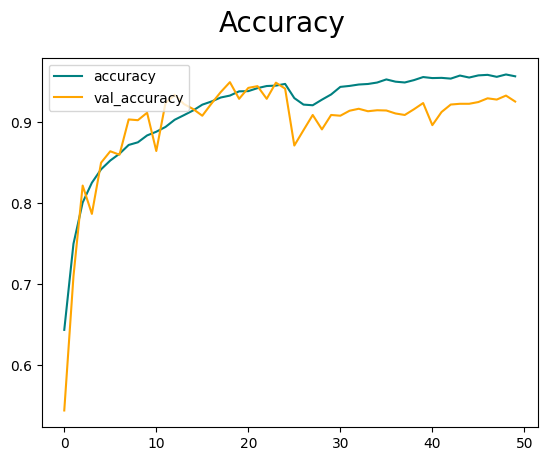

In [33]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

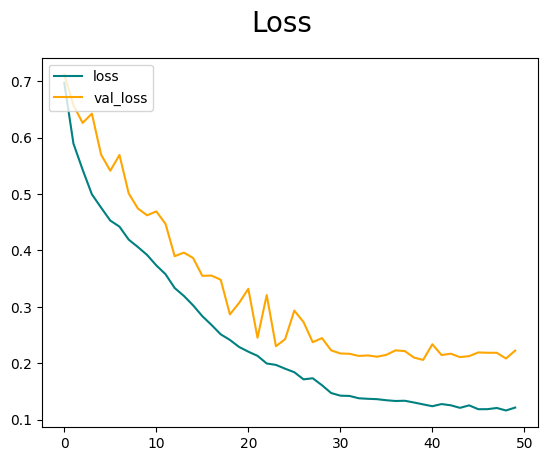

In [34]:
fig = plt.figure()
plt.plot(history.history['loss'], color = 'teal', label = 'loss')
plt.plot(history.history['val_loss'], color = 'orange', label = 'val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc='upper left')
plt.show()

## Evaluating the performance

In [35]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [36]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [37]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [38]:
print(f"Precision: {pre.result().numpy()}\nRecall: {re.result().numpy()}\n Accuracy: {acc.result().numpy()}")

Precision: 0.7591463327407837
Recall: 0.8440678119659424
 Accuracy: 0.9223361015319824


## Testing using outside data.

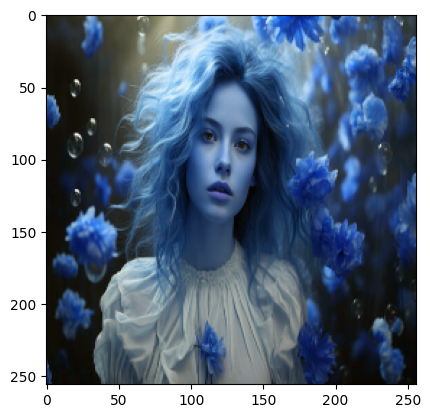

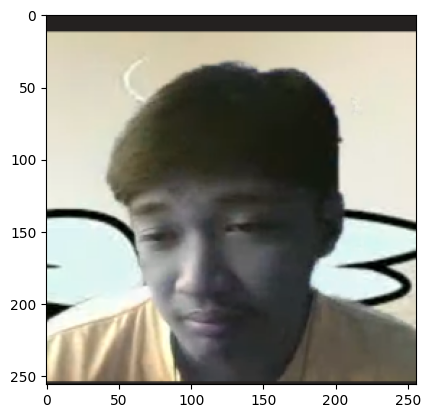

In [39]:
imgfakeloc = "C:\\Users\\Divino\\Documents\\Others(anditoyungprogrammingfile)\\Programming\\2nd_Year_BSCS\\Introduction_To_AI\\Image Classification\\Final Project\\test_AI.jpg"
imgrealloc = r"C:\Users\Divino\Documents\Others(anditoyungprogrammingfile)\Programming\2nd_Year_BSCS\Introduction_To_AI\Image Classification\Final Project\real.png"
img1 = cv2.imread(imgfakeloc)
img2 = cv2.imread(imgrealloc)
img3_feet = cv2.imread('test.jpg')
img4_ai = cv2.imread('TestAi.png')

resize1 = tf.image.resize(img1, (256, 256))
resize2 = tf.image.resize(img2, (256, 256))
resized_feet = tf.image.resize(img3_feet, (256, 256))
resized_ai = tf.image.resize(img4_ai, (256, 256))


plt.imshow(resize1.numpy().astype(int))
plt.show()

plt.imshow(resize2.numpy().astype(int))
plt.show()


In [40]:
def detect(x):
    if x < 0.5:
        print("Predicted class is AI generated")
    else:
        print("Predicted class is a Real image")

In [42]:
yhat = model.predict(np.expand_dims(resize1/255, 0))
detect(yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted class is AI generated


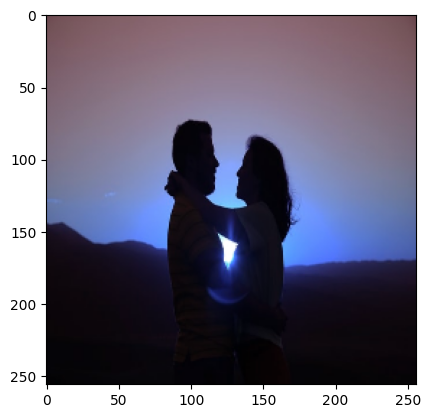

In [43]:
nagmamahalan = cv2.imread("what-is-love_orig.jpg")
resizedNagmamahalan = tf.image.resize(nagmamahalan, (256,256))
plt.imshow(resizedNagmamahalan.numpy().astype(int))
plt.show()

In [44]:
yhat = model.predict(np.expand_dims(resizedNagmamahalan/255, 0))
detect(yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class is a Real image


In [45]:
detect(yhat)
# my model has successfully detected the ai generated image.

Predicted class is a Real image


In [46]:
yhat = model.predict(np.expand_dims(resize2/255, 0))
detect(yhat)
# my model has successfully detected the human made image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted class is AI generated


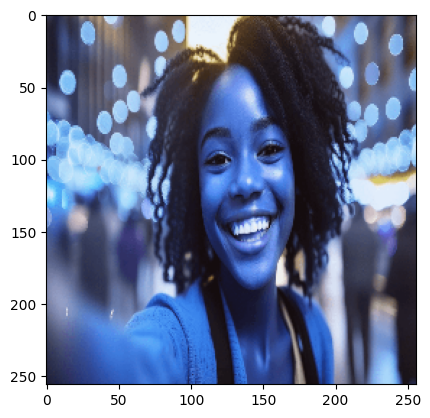

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted class is AI generated


In [47]:
plt.imshow(resized_ai.numpy().astype(int))
plt.show()

yhat = model.predict(np.expand_dims(resized_ai/255, 0))
detect(yhat)

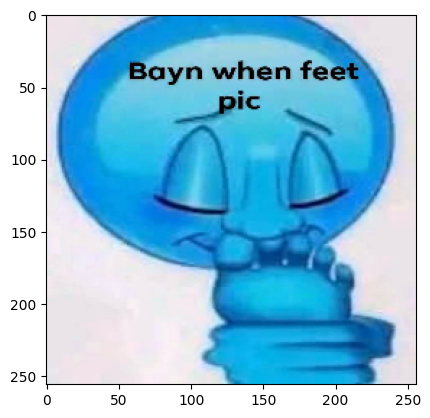

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted class is a Real image


In [48]:
plt.imshow(resized_feet.numpy().astype(int))
plt.show()

yhat = model.predict(np.expand_dims(resized_feet/255, 0))
detect(yhat)

# SAVE THE MODEL

In [49]:
from tensorflow.keras.models import load_model

In [50]:
model.save(os.path.join('models', 'aiDetectionV2.h5'))

In [ ]:
# new_model = load_model(os.path.join('models', 'airealmode.h5'))

In [ ]:
# yhat_new = new_model.predict(np.expand_dims(resize2/255, 0))
# detect(yhat_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted class is a Real image
